# CNN SU(3) downsampling: L24 → L12

Fine L24 configurations are stout-smeared with a link-local CNN, projected back to SU(3), and blocked by a factor of two. The histograms compare that ensemble with the native L12 reference and with naive two-link blocking, on all 300 configurations.

In [1]:
from pathlib import Path
import csv, json, os, sys
import numpy as np
import matplotlib.pyplot as plt

ROOT = next(path for path in (Path.cwd(), Path.cwd().parent) if (path / 'artifacts').exists())
RUN = Path(os.environ.get('RGFLOW_DOWNSAMPLE_RUN', ROOT / 'artifacts' / '4dsu3' / 'downsample' / 'L24_beta6p20_to_L12_beta5p80_cnn_v2'))
for filename in ('history.csv', 'metrics.json', 'kernel.json', 'observable_distributions.npz'):
    if not (RUN / filename).exists():
        raise FileNotFoundError(f'{RUN / filename} not found; run scripts/downsample/train.py first')
with (RUN / 'history.csv').open(newline='', encoding='utf-8') as stream:
    rows = list(csv.DictReader(stream))
history = {key: np.asarray([float(row[key]) for row in rows]) for key in rows[0]}
metrics = json.loads((RUN / 'metrics.json').read_text(encoding='utf-8'))
kernel = json.loads((RUN / 'kernel.json').read_text(encoding='utf-8'))
saved = np.load(RUN / 'observable_distributions.npz')
names = tuple(metrics['observables'])
reference = saved['reference_all']
baseline = np.empty_like(reference)
downsampled = np.empty_like(reference)
for split, indices in kernel['data_split'].items():
    baseline[np.asarray(indices)] = saved[f'baseline_{split}']
    downsampled[np.asarray(indices)] = saved[f'trained_{split}']
sys.path.insert(0, str(ROOT / 'scripts' / 'heatbath'))
from plot_settings import (
    BLUE, FIG_SIZE, FONT_SIZE, GREEN, LABEL_SIZE, LEGEND_SIZE, ORANGE, apply_plot_style, default_plot,
)

apply_plot_style()
plt.rcParams.update({
    'axes.labelsize': FONT_SIZE['fontsize'],
    'axes.titlesize': FONT_SIZE['fontsize'],
    'legend.fontsize': LEGEND_SIZE['fontsize'],
    'axes.formatter.use_mathtext': True,
})

def style_axis(axis):
    axis.tick_params(direction='in', top=True, right=True, **LABEL_SIZE)
    axis.grid(linestyle=':')

print(f'{RUN.name}: {len(reference)} configurations, best epoch {metrics["best_epoch"]}')

L24_beta6p20_to_L12_beta5p80_cnn_v2: 300 configurations, best epoch 4


## Training loss

Each epoch uses a rotating subset of 30 of the 180 training configurations. The plotted loss is the covariance-weighted mean mismatch plus the standardized log-variance mismatch. The checkpoint is the epoch with the lowest validation loss.

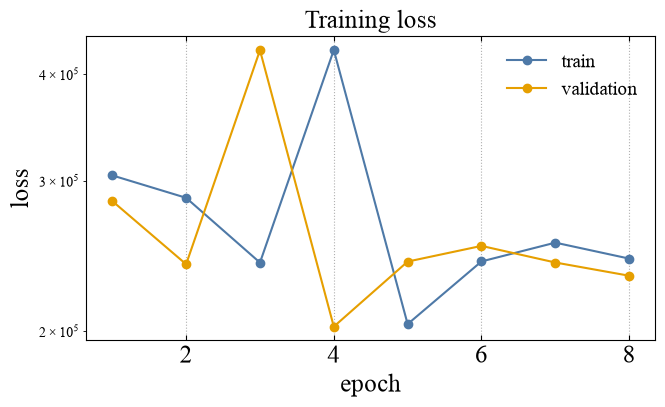

In [2]:
figure, axis = default_plot()
axis.plot(history['epoch'], history['train_loss'], 'o-', color=BLUE, label='train')
axis.plot(history['epoch'], history['validation_loss'], 'o-', color=ORANGE, label='validation')
axis.set_xlabel('epoch')
axis.set_ylabel('loss')
axis.set_title('Training loss')
axis.set_yscale('log')
axis.legend(frameon=False)
figure.tight_layout()
plt.show()

## Observable distributions

Reference L12, CNN downsampling, and naive downsampling are each histogrammed with their own Freedman–Diaconis bins. The shared axis covers all three samples.

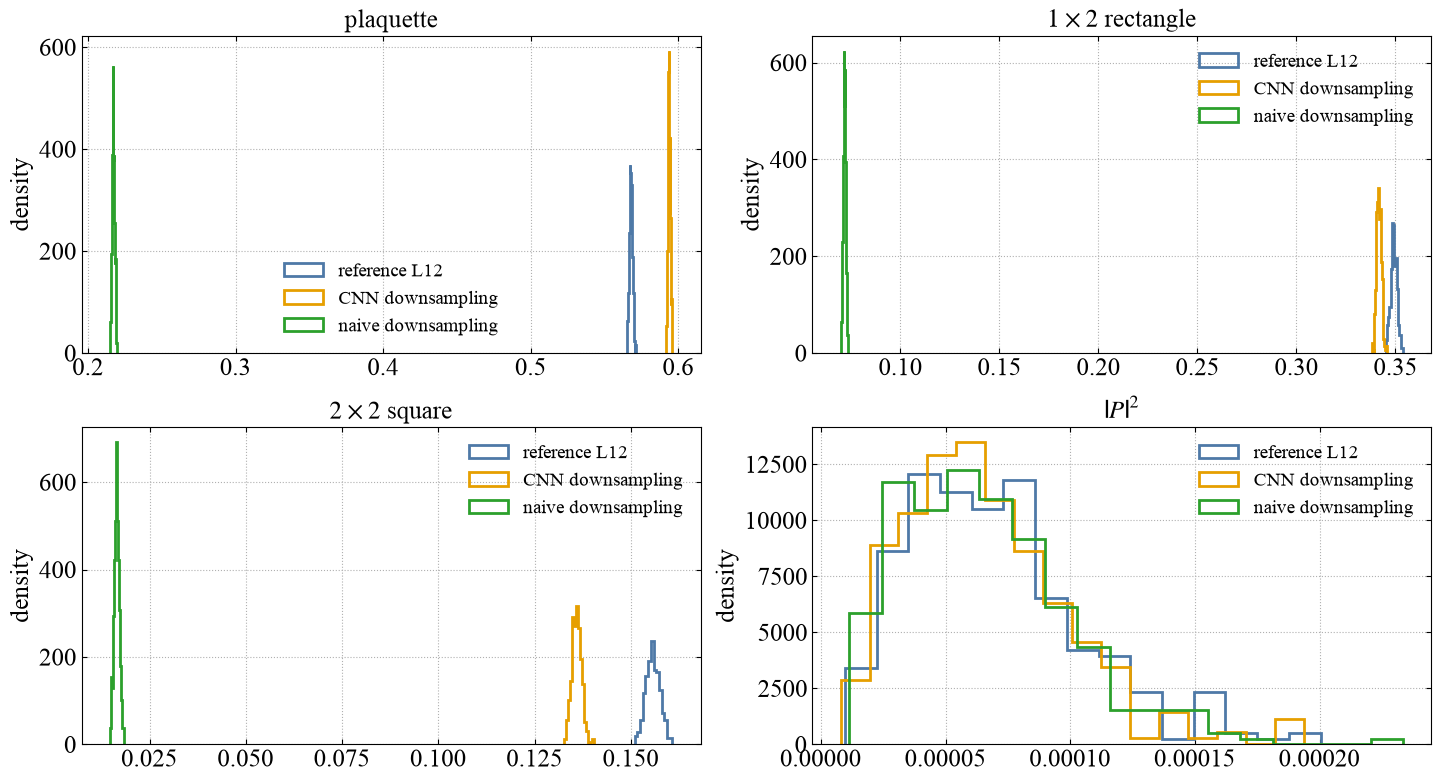

In [3]:
def sample_bins(values, minimum=12, maximum=40):
    values = np.asarray(values, dtype=float)
    lower, upper = float(values.min()), float(values.max())
    if upper <= lower:
        pad = 0.5 if upper == lower else 0.05 * max(abs(lower), 1.0)
        return np.linspace(lower - pad, upper + pad, minimum + 1)
    iqr = float(np.percentile(values, 75) - np.percentile(values, 25))
    width = 2.0 * iqr * len(values) ** (-1.0 / 3.0)
    count = minimum if width <= 0 else int(np.ceil((upper - lower) / width))
    count = int(np.clip(count, minimum, maximum))
    return np.linspace(lower, upper, count + 1)

labels = {
    'plaquette': 'plaquette',
    'rectangle_1x2': r'$1\times 2$ rectangle',
    'square_2x2': r'$2\times 2$ square',
    'polyakov_abs2': r'$|P|^2$',
}
series = (
    (reference, BLUE, 'reference L12'),
    (downsampled, ORANGE, 'CNN downsampling'),
    (baseline, GREEN, 'naive downsampling'),
)
figure, axes = plt.subplots(2, 2, figsize=(FIG_SIZE[0] * 2.15, FIG_SIZE[1] * 1.9))
for index, (axis, name) in enumerate(zip(axes.flat, names)):
    for sample, color, label in series:
        values = sample[:, index]
        axis.hist(values, bins=sample_bins(values), density=True, histtype='step', linewidth=2.0, color=color, label=label)
    style_axis(axis)
    axis.set_title(labels.get(name, name))
    axis.set_ylabel('density')
    axis.legend(frameon=False)
figure.tight_layout()
plt.show()

## CNN design

One downsampling step is a stout smearing with link-local weights, an SU(3) projection, then a factor-of-two blocking.

### Stout smearing

For each fine link $U_\mu(x)$ the unsmeared matrix is a mixture of the straight link and two path averages. The staple average $C_\mu(x)$ is the mean of the six staples. For every transverse direction $\nu\neq\mu$,

\begin{aligned}
S^{+\nu}_\mu(x) &= U_\nu(x)\,U_\mu(x+\hat\nu)\,U_\nu^\dagger(x+\hat\mu),\\
S^{-\nu}_\mu(x) &= U_\nu^\dagger(x-\hat\nu)\,U_\mu(x-\hat\nu)\,U_\nu(x-\hat\nu+\hat\mu).
\end{aligned}

The rectangle average $R_\mu(x)$ is the mean of the six transverse $1\times 2$ paths from $x$ to $x+\hat\mu$: two steps along $\pm\nu$, one step along $\mu$, and two steps back.

The CNN gives three positive weights that sum to one,

\begin{aligned}
\Omega_\mu(x) = w^{(0)}_\mu(x)\,U_\mu(x) + w^{(1)}_\mu(x)\,C_\mu(x) + w^{(2)}_\mu(x)\,R_\mu(x).
\end{aligned}

Its input is 48 gauge-invariant channels: for each of the four link directions and three transverse directions, the real and imaginary parts of the traced forward and backward plaquettes. Two periodic convolutions, $48\to 16$ and $16\to 16$, use kernel size 3 and a GELU. A last convolution, $16\to 12$ with kernel size 1, produces three logits on each direction. Those logits are

\begin{aligned}
0.1\,\mathrm{CNN}(x) + \log(0.30,\,0.65,\,0.05),
\end{aligned}

and the weights are their softmax. Training therefore starts from a spatially constant mixture, and the network learns a link-dependent correction. Each periodic convolution is a circular Conv3d on $(z,y,x)$ followed by a circular Conv1d on $t$.

$\Omega_\mu(x)$ is then replaced by the nearest SU(3) matrix: the polar factor from the SVD, multiplied by the phase that sets the determinant to one. That projected field is $U^{\mathrm{stout}}$.

### Blocking

The coarse lattice keeps the all-even sublattice. In every $2^4$ block the anchor is the site $x=2y$ whose four coordinates are even, and the coarse link is the product of the two stout links that cross the block,

\begin{aligned}
V_\mu(y) = U^{\mathrm{stout}}_\mu(2y)\,U^{\mathrm{stout}}_\mu(2y+\hat\mu).
\end{aligned}

The product is already in SU(3), and every extent is halved, so $24^4\to 12^4$. Naive downsampling is the same product with weights $(1,0,0)$: the straight links only, with no staple, rectangle, or projection.